# IA PARA CIENCIA DE DATOS

## Contenido

1. Cargar librerías
1. Leer archivo y procesar datos
1. ML methods
1. Fine-tuning
1. Model Comparison

## 1. Cargar librerías

In [1]:
import warnings
warnings.filterwarnings("ignore")
import math
import numpy as np # to use numpy arrays instead of lists
import pandas as pd # DataFrame (table)

# Matplotlib and seaborn for charting
import matplotlib.pyplot as plt # to plot
import seaborn as sns # to plot

np.random.seed(0)

In [2]:
# Sklearn processing modules
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# sklearn algorithms for ML
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn import svm
from sklearn.neighbors import KNeighborsClassifier

# Sklearn to find the best hyperparameters
from sklearn.model_selection import GridSearchCV

In [3]:
# Sklearn classification model evaluation metrics
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

In [4]:
# Wilcoxon signed-rank test
from scipy.stats import wilcoxon
# α = 0.05
# Valor p ≤ α: La diferencia entre las medianas es significativamente diferente (Rechaza H0) 
# Valor p > α: La diferencia entre las medianas no es significativamente diferente (No puede rechazar H0) 

## 2. Leer archivo y procesar datos

### 2.1 Leer archivo

In [5]:
dataSet = pd.read_csv("Amazon_Unlocked_Mobile.zip", compression='zip', header=0)
print(dataSet)

                                             Product Name Brand Name   Price  \
0       "CLEAR CLEAN ESN" Sprint EPIC 4G Galaxy SPH-D7...    Samsung  199.99   
1       "CLEAR CLEAN ESN" Sprint EPIC 4G Galaxy SPH-D7...    Samsung  199.99   
2       "CLEAR CLEAN ESN" Sprint EPIC 4G Galaxy SPH-D7...    Samsung  199.99   
3       "CLEAR CLEAN ESN" Sprint EPIC 4G Galaxy SPH-D7...    Samsung  199.99   
4       "CLEAR CLEAN ESN" Sprint EPIC 4G Galaxy SPH-D7...    Samsung  199.99   
...                                                   ...        ...     ...   
413835  Samsung Convoy U640 Phone for Verizon Wireless...    Samsung   79.95   
413836  Samsung Convoy U640 Phone for Verizon Wireless...    Samsung   79.95   
413837  Samsung Convoy U640 Phone for Verizon Wireless...    Samsung   79.95   
413838  Samsung Convoy U640 Phone for Verizon Wireless...    Samsung   79.95   
413839  Samsung Convoy U640 Phone for Verizon Wireless...    Samsung   79.95   

        Rating                         

### 2.2 Preprocesamiento

NOTA: cambio en el etiquetado

In [6]:
dataSet.dropna(inplace=True)
dataSet = dataSet.iloc[0:100000,:]

# Encode 4s and 5s as positive
dataSet['Sentiment'] = 0

for row in range(len(dataSet)):
  if dataSet.iloc[row,3] > 3:
    dataSet.iloc[row,6] = 1

datos = ['Reviews', 'Rating', 'Sentiment']
misDatos = dataSet[datos]
print(misDatos.head(10))
print()

misDatos = misDatos[['Reviews', 'Sentiment']]
print(misDatos.head(10))
print()

size = len(misDatos)
print("Percentage of positive comments: ", round(misDatos['Sentiment'].sum()/size, 2))  # Number of positive comments
print("Percentage of negative comments: ", round((size - misDatos['Sentiment'].sum())/size, 2))  # Number of negative comments

                                             Reviews  Rating  Sentiment
0  I feel so LUCKY to have found this used (phone...       5          1
1  nice phone, nice up grade from my pantach revu...       4          1
2                                       Very pleased       5          1
3  It works good but it goes slow sometimes but i...       4          1
4  Great phone to replace my lost phone. The only...       4          1
5  I already had a phone with problems... I know ...       1          0
6  The charging port was loose. I got that solder...       2          0
7  Phone looks good but wouldn't stay charged, ha...       2          0
8  I originally was using the Samsung S2 Galaxy f...       5          1
9  It's battery life is great. It's very responsi...       3          0

                                             Reviews  Sentiment
0  I feel so LUCKY to have found this used (phone...          1
1  nice phone, nice up grade from my pantach revu...          1
2              

### 2.3 Split Data

In [7]:
# Split data into train and test sets
train_size = 0.75
test_size = 1 - train_size
trainSet, testSet = train_test_split(misDatos, test_size=test_size, shuffle=True, stratify=misDatos['Sentiment'], random_state=0)

print("Train set")
print(trainSet.head())
print()
print('trainSet shape: ', trainSet.shape)
print()

size = len(trainSet)
print("Percentage of positive comments: ", round(trainSet['Sentiment'].sum()/size, 2))  # Number of positive comments
print("Percentage of negative comments: ", round((size - trainSet['Sentiment'].sum())/size, 2))  # Number of negative comments
print()

print("Test set")
print(testSet.head())
print()
print('testSet shape: ', testSet.shape)
print()

size = len(testSet)
print("Percentage of positive comments: ", round(testSet['Sentiment'].sum()/size, 2))  # Number of positive comments
print("Percentage of negative comments: ", round((size - testSet['Sentiment'].sum())/size, 2))  # Number of negative comments

Train set
                                                  Reviews  Sentiment
112995  good new product in accordance with my purchase .          1
36013                                  Thanks thata great          1
75170   It attended my expectation on processor speed,...          1
108974  I was very pleased with my phone. I got it in ...          1
73862                                   Very good tanks 😊          1

trainSet shape:  (75000, 2)

Percentage of positive comments:  0.7
Percentage of negative comments:  0.3

Test set
                                                 Reviews  Sentiment
7650   I need you to do the reverse in a gift card no...          0
68968  Phone was not unlocked as it was said but othe...          0
62027  I love this phone it was delivered as promised...          1
7022                                               GREAT          1
94315            Was a no good. Battery was not charging          0

testSet shape:  (25000, 2)

Percentage of positive 

### 2.4 Vectorizar datos

In [8]:
vectorizer = TfidfVectorizer(stop_words='english',  ## NOTA: este se quita porque los comentarios están en español
                             min_df = 5,
                             max_df = 0.8,
                             sublinear_tf = True,
                             use_idf = True)
train_vectors = vectorizer.fit_transform(trainSet['Reviews'])
test_vectors = vectorizer.transform(testSet['Reviews'])

print(train_vectors)
print("\n")
print(test_vectors)

  (0, 3888)	0.21915011114716768
  (0, 5614)	0.2575520211358784
  (0, 6443)	0.28692454330993816
  (0, 446)	0.8259386081348773
  (0, 6557)	0.34805158702642497
  (1, 8312)	0.8627365069850135
  (1, 3957)	0.505653754574509
  (2, 946)	0.3828999899039345
  (2, 3298)	0.283053074996871
  (2, 6434)	0.2473894674951817
  (2, 7825)	0.2333580304986499
  (2, 5811)	0.38739729530704486
  (2, 838)	0.1760030608349749
  (2, 6371)	0.19588594944271331
  (2, 6617)	0.21489796027015526
  (2, 1089)	0.1407464664867978
  (2, 2302)	0.2713763635262984
  (2, 8792)	0.24595294833936132
  (2, 4819)	0.24479580027241807
  (2, 4989)	0.17765592830048021
  (2, 1197)	0.2034603057429238
  (2, 2335)	0.17445489077484236
  (2, 3302)	0.17232965217916846
  (2, 7690)	0.21223236591741668
  (3, 6196)	0.5588735328890356
  :	:
  (74992, 5846)	0.44080369595342206
  (74993, 5761)	1.0
  (74994, 6108)	0.28277967439512397
  (74994, 1449)	0.3481950737327303
  (74994, 4075)	0.3815718728687574
  (74994, 8861)	0.4302672053086997
  (74994, 6708)

## 3. ML methods

In [9]:
# DataFrames to store model predictions
columnsNames = ['Sentiment', 'Log Reg Sentiment', 'DT Sentiment', 'RF Sentiment', 'SVM Sentiment', 'KNN Sentiment', 'Grid Log Reg Sentiment', 'Grid DT Sentiment', 'Grid RF Sentiment', 'Grid SVM Sentiment', 'Grid KNN Sentiment']
trainModel = pd.DataFrame(columns=columnsNames)
testModel = pd.DataFrame(columns=columnsNames)
trainModel['Sentiment'] = trainSet['Sentiment']
testModel['Sentiment'] = testSet['Sentiment']
print(trainModel.head())
print()
print(testModel.head())

        Sentiment Log Reg Sentiment DT Sentiment RF Sentiment SVM Sentiment  \
112995          1               NaN          NaN          NaN           NaN   
36013           1               NaN          NaN          NaN           NaN   
75170           1               NaN          NaN          NaN           NaN   
108974          1               NaN          NaN          NaN           NaN   
73862           1               NaN          NaN          NaN           NaN   

       KNN Sentiment Grid Log Reg Sentiment Grid DT Sentiment  \
112995           NaN                    NaN               NaN   
36013            NaN                    NaN               NaN   
75170            NaN                    NaN               NaN   
108974           NaN                    NaN               NaN   
73862            NaN                    NaN               NaN   

       Grid RF Sentiment Grid SVM Sentiment Grid KNN Sentiment  
112995               NaN                NaN                NaN  
3601

In [10]:
# DataFrames to store model performance metrics
methodsUsed=['Log Reg', 'DT', 'RF', 'SVM', 'KNN', 'Grid Log Reg', 'Grid DT', 'Grid RF', 'Grid SVM', 'Grid KNN']
performanceHeaders=['accuracy', 'precision','recall','f1-score']
trainModelMetrics = pd.DataFrame(index=methodsUsed, columns=performanceHeaders)
testModelMetrics = pd.DataFrame(index=methodsUsed, columns=performanceHeaders)
print(trainModelMetrics)
print()
print(testModelMetrics)

             accuracy precision recall f1-score
Log Reg           NaN       NaN    NaN      NaN
DT                NaN       NaN    NaN      NaN
RF                NaN       NaN    NaN      NaN
SVM               NaN       NaN    NaN      NaN
KNN               NaN       NaN    NaN      NaN
Grid Log Reg      NaN       NaN    NaN      NaN
Grid DT           NaN       NaN    NaN      NaN
Grid RF           NaN       NaN    NaN      NaN
Grid SVM          NaN       NaN    NaN      NaN
Grid KNN          NaN       NaN    NaN      NaN

             accuracy precision recall f1-score
Log Reg           NaN       NaN    NaN      NaN
DT                NaN       NaN    NaN      NaN
RF                NaN       NaN    NaN      NaN
SVM               NaN       NaN    NaN      NaN
KNN               NaN       NaN    NaN      NaN
Grid Log Reg      NaN       NaN    NaN      NaN
Grid DT           NaN       NaN    NaN      NaN
Grid RF           NaN       NaN    NaN      NaN
Grid SVM          NaN       NaN    NaN 

In [11]:
def computeModel(model, modelName, trainModel, testModel, train_vectors, test_vectors, trainSet):
    model.fit(train_vectors, trainSet.iloc[:,1:])

    trainModel[modelName] = model.predict(train_vectors)
    testModel[modelName] = model.predict(test_vectors)
    
    return trainModel, testModel

In [12]:
def compareMethod(position, modelName, trainModelMetrics, testModelMetrics, trainModel, testModel):
    # --- Train Metrics ---
    trainModelMetrics.iloc[position, 0] = accuracy_score(trainModel['Sentiment'], trainModel[modelName])
    trainModelMetrics.iloc[position, 1] = precision_score(trainModel['Sentiment'], trainModel[modelName], average='macro', zero_division=0)
    trainModelMetrics.iloc[position, 2] = recall_score(trainModel['Sentiment'], trainModel[modelName], average='macro', zero_division=0)
    trainModelMetrics.iloc[position, 3] = f1_score(trainModel['Sentiment'], trainModel[modelName], average='macro', zero_division=0)

    # --- Test Metrics ---
    testModelMetrics.iloc[position, 0] = accuracy_score(testModel['Sentiment'], testModel[modelName])
    testModelMetrics.iloc[position, 1] = precision_score(testModel['Sentiment'], testModel[modelName ], average='macro', zero_division=0)
    testModelMetrics.iloc[position, 2] = recall_score(testModel['Sentiment'], testModel[modelName], average='macro', zero_division=0)
    testModelMetrics.iloc[position, 3] = f1_score(testModel['Sentiment'], testModel[modelName], average='macro', zero_division=0)

    return trainModelMetrics, testModelMetrics

In [13]:
# Perform classification with Logistic Regression
print('Classification with Logistic Regression')
modelName = 'Log Reg Sentiment'
postion = 0
classifier_log_reg = LogisticRegression()
trainModel, testModel = computeModel(classifier_log_reg, modelName, trainModel, testModel, train_vectors, test_vectors, trainSet)

print(testModel)

trainModelMetrics, testModelMetrics = compareMethod(postion, modelName, trainModelMetrics, testModelMetrics, trainModel, testModel)

print(trainModelMetrics)
print()
print(testModelMetrics)
print()

# Detailed classification report
report = classification_report(trainModel['Sentiment'], trainModel[modelName])
print("Detailed Classification Report for Decision Tree:")
print(report)

Classification with Logistic Regression
        Sentiment  Log Reg Sentiment DT Sentiment RF Sentiment SVM Sentiment  \
7650            0                  0          NaN          NaN           NaN   
68968           0                  1          NaN          NaN           NaN   
62027           1                  1          NaN          NaN           NaN   
7022            1                  1          NaN          NaN           NaN   
94315           0                  0          NaN          NaN           NaN   
...           ...                ...          ...          ...           ...   
71226           1                  1          NaN          NaN           NaN   
92109           1                  1          NaN          NaN           NaN   
102395          0                  1          NaN          NaN           NaN   
47778           0                  0          NaN          NaN           NaN   
45250           0                  0          NaN          NaN           NaN   


In [14]:
# Perform classification with DT
print('Classification with DT')
modelName = 'DT Sentiment'
postion = 1
classifier_dt = DecisionTreeClassifier(max_depth=5)
trainModel, testModel = computeModel(classifier_dt, modelName, trainModel, testModel, train_vectors, test_vectors, trainSet)

print(testModel)

trainModelMetrics, testModelMetrics = compareMethod(postion, modelName, trainModelMetrics, testModelMetrics, trainModel, testModel)

print(trainModelMetrics)
print()
print(testModelMetrics)
print()

# Detailed classification report
report = classification_report(trainModel['Sentiment'], trainModel[modelName])
print("Detailed Classification Report for Decision Tree:")
print(report)

Classification with DT
        Sentiment  Log Reg Sentiment  DT Sentiment RF Sentiment SVM Sentiment  \
7650            0                  0             1          NaN           NaN   
68968           0                  1             0          NaN           NaN   
62027           1                  1             1          NaN           NaN   
7022            1                  1             1          NaN           NaN   
94315           0                  0             0          NaN           NaN   
...           ...                ...           ...          ...           ...   
71226           1                  1             1          NaN           NaN   
92109           1                  1             1          NaN           NaN   
102395          0                  1             1          NaN           NaN   
47778           0                  0             1          NaN           NaN   
45250           0                  0             1          NaN           NaN   

    

In [15]:
# Perform the class with RF
print('Classification with RF')
modelName = 'RF Sentiment'
postion = 2
classifier_rf = RandomForestClassifier(n_estimators=100, max_depth=5)
trainModel, testModel = computeModel(classifier_rf, modelName, trainModel, testModel, train_vectors, test_vectors, trainSet)

print(testModel)

trainModelMetrics, testModelMetrics = compareMethod(postion, modelName, trainModelMetrics, testModelMetrics, trainModel, testModel)

print(trainModelMetrics)
print()
print(testModelMetrics)
print()

# Detailed classification report
report = classification_report(trainModel['Sentiment'], trainModel[modelName])
print("Detailed Classification Report for Random Forest:")
print(report)

Classification with RF
        Sentiment  Log Reg Sentiment  DT Sentiment  RF Sentiment  \
7650            0                  0             1             1   
68968           0                  1             0             1   
62027           1                  1             1             1   
7022            1                  1             1             1   
94315           0                  0             0             1   
...           ...                ...           ...           ...   
71226           1                  1             1             1   
92109           1                  1             1             1   
102395          0                  1             1             1   
47778           0                  0             1             1   
45250           0                  0             1             1   

       SVM Sentiment KNN Sentiment Grid Log Reg Sentiment Grid DT Sentiment  \
7650             NaN           NaN                    NaN               NaN   
68

In [16]:
# Perform the class with SVM
print('Classification with SVM')
modelName = 'SVM Sentiment'
postion = 3
classifier_svm = svm.SVC()
trainModel, testModel = computeModel(classifier_dt, modelName, trainModel, testModel, train_vectors, test_vectors, trainSet)

print(testModel)

trainModelMetrics, testModelMetrics = compareMethod(postion, modelName, trainModelMetrics, testModelMetrics, trainModel, testModel)

print(trainModelMetrics)
print()
print(testModelMetrics)
print()

# Detailed classification report
report = classification_report(trainModel['Sentiment'], trainModel[modelName])
print("Detailed Classification Report for SVM:")
print(report)

Classification with SVM
        Sentiment  Log Reg Sentiment  DT Sentiment  RF Sentiment  \
7650            0                  0             1             1   
68968           0                  1             0             1   
62027           1                  1             1             1   
7022            1                  1             1             1   
94315           0                  0             0             1   
...           ...                ...           ...           ...   
71226           1                  1             1             1   
92109           1                  1             1             1   
102395          0                  1             1             1   
47778           0                  0             1             1   
45250           0                  0             1             1   

        SVM Sentiment KNN Sentiment Grid Log Reg Sentiment Grid DT Sentiment  \
7650                1           NaN                    NaN               NaN   

In [17]:
# Perform the class with KNN
print('Classification with KNN')
modelName = 'KNN Sentiment'
postion = 4
classifier_knn = KNeighborsClassifier(n_neighbors=2)
trainModel, testModel = computeModel(classifier_knn, modelName, trainModel, testModel, train_vectors, test_vectors, trainSet)
print(testModel)

trainModelMetrics, testModelMetrics = compareMethod(postion, modelName, trainModelMetrics, testModelMetrics, trainModel, testModel)

print(trainModelMetrics)
print()
print(testModelMetrics)
print()

# Detailed classification report
report = classification_report(trainModel['Sentiment'], trainModel[modelName])
print("Detailed Classification Report for KNN:")
print(report)

Classification with KNN
        Sentiment  Log Reg Sentiment  DT Sentiment  RF Sentiment  \
7650            0                  0             1             1   
68968           0                  1             0             1   
62027           1                  1             1             1   
7022            1                  1             1             1   
94315           0                  0             0             1   
...           ...                ...           ...           ...   
71226           1                  1             1             1   
92109           1                  1             1             1   
102395          0                  1             1             1   
47778           0                  0             1             1   
45250           0                  0             1             1   

        SVM Sentiment  KNN Sentiment Grid Log Reg Sentiment Grid DT Sentiment  \
7650                1              0                    NaN               NaN 

## 4. Fine-tuning

In [18]:
def computeGridModel(model, param_search, modelName, trainModel, testModel, train_vectors, test_vectors, trainSet):
    grid_search = GridSearchCV(model, param_search, cv=5, verbose=1)
    grid_search.fit(train_vectors, trainSet.iloc[:,1:])

    best_model = grid_search.best_estimator_
    print("Best parameters found: ", best_model.get_params())
    print("\n")

    trainModel[modelName] = best_model.predict(train_vectors)
    testModel[modelName] = best_model.predict(test_vectors)
    
    return trainModel, testModel

In [19]:
# Perform classification with Logistic Regression
print('Classification with Logistic Regression')
modelName = 'Grid Log Reg Sentiment'
postion = 5
log_reg_clf = LogisticRegression()
param_search_log_reg = {
        'solver': ['lbfgs', 'saga']
    }

trainModel, testModel = computeGridModel(log_reg_clf, param_search_log_reg, modelName, trainModel, testModel, train_vectors, test_vectors, trainSet)
print(testModel)

trainModelMetrics, testModelMetrics = compareMethod(postion, modelName, trainModelMetrics, testModelMetrics, trainModel, testModel)

print(trainModelMetrics)
print()
print(testModelMetrics)
print()

# Detailed classification report
report = classification_report(trainModel['Sentiment'], trainModel[modelName])
print("Detailed Classification Report for Grid Search Logistic Regression:")
print(report)

Classification with Logistic Regression
Fitting 5 folds for each of 2 candidates, totalling 10 fits


Best parameters found:  {'C': 1.0, 'class_weight': None, 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': None, 'max_iter': 100, 'multi_class': 'deprecated', 'n_jobs': None, 'penalty': 'l2', 'random_state': None, 'solver': 'saga', 'tol': 0.0001, 'verbose': 0, 'warm_start': False}


        Sentiment  Log Reg Sentiment  DT Sentiment  RF Sentiment  \
7650            0                  0             1             1   
68968           0                  1             0             1   
62027           1                  1             1             1   
7022            1                  1             1             1   
94315           0                  0             0             1   
...           ...                ...           ...           ...   
71226           1                  1             1             1   
92109           1                  1             1             1   
102395          0                  1             1             1   
47778       

In [20]:
# Perform classification with DT
print('Classification with DT')
modelName = 'Grid DT Sentiment'
postion = 6
dt_clf = DecisionTreeClassifier()
param_search_dt = {
        'criterion': ["gini", 'entropy'],
        'max_depth': [5, 10, 20, 30, None]
    }

trainModel, testModel = computeGridModel(dt_clf, param_search_dt, modelName, trainModel, testModel, train_vectors, test_vectors, trainSet)

print(testModel)

trainModelMetrics, testModelMetrics = compareMethod(postion, modelName, trainModelMetrics, testModelMetrics, trainModel, testModel)

print(trainModelMetrics)
print()
print(testModelMetrics)
print()

# Detailed classification report
report = classification_report(trainModel['Sentiment'], trainModel[modelName])
print("Detailed Classification Report for Grid Search Decision Tree:")
print(report)

Classification with DT
Fitting 5 folds for each of 10 candidates, totalling 50 fits


Best parameters found:  {'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': None, 'splitter': 'best'}


        Sentiment  Log Reg Sentiment  DT Sentiment  RF Sentiment  \
7650            0                  0             1             1   
68968           0                  1             0             1   
62027           1                  1             1             1   
7022            1                  1             1             1   
94315           0                  0             0             1   
...           ...                ...           ...           ...   
71226           1                  1             1             1   
92109           1                  1             1             1   
102395          0                  1             1          

In [21]:
# Perform classification with RF
print('Classification with RF')
modelName = 'Grid RF Sentiment'
postion = 7
rf_clf = RandomForestClassifier()
param_search_rf = {
        'n_estimators': [75, 100],
        'max_depth': [5, 15, None]
    }

trainModel, testModel = computeGridModel(dt_clf, param_search_dt, modelName, trainModel, testModel, train_vectors, test_vectors, trainSet)

print(testModel)

trainModelMetrics, testModelMetrics = compareMethod(postion, modelName, trainModelMetrics, testModelMetrics, trainModel, testModel)

print(trainModelMetrics)
print()
print(testModelMetrics)
print()

# Detailed classification report
report = classification_report(trainModel['Sentiment'], trainModel[modelName])
print("Detailed Classification Report for Grid Search Random Forest:")
print(report)

Classification with RF
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best parameters found:  {'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': None, 'splitter': 'best'}


        Sentiment  Log Reg Sentiment  DT Sentiment  RF Sentiment  \
7650            0                  0             1             1   
68968           0                  1             0             1   
62027           1                  1             1             1   
7022            1                  1             1             1   
94315           0                  0             0             1   
...           ...                ...           ...           ...   
71226           1                  1             1             1   
92109           1                  1        

In [22]:
# Perform the class with SVM
print('Classification with SVM')
modelName = 'Grid SVM Sentiment'
postion = 8
svm_clf = svm.SVC()
param_search_svm = {
        'kernel': ['poly']
    }

trainModel, testModel = computeGridModel(dt_clf, param_search_dt, modelName, trainModel, testModel, train_vectors, test_vectors, trainSet)

print(testModel)

trainModelMetrics, testModelMetrics = compareMethod(postion, modelName, trainModelMetrics, testModelMetrics, trainModel, testModel)

print(trainModelMetrics)
print()
print(testModelMetrics)
print()

# Detailed classification report
report = classification_report(trainModel['Sentiment'], trainModel[modelName])
print("Detailed Classification Report for Grid Search SVM:")
print(report)

Classification with SVM
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best parameters found:  {'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'entropy', 'max_depth': None, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': None, 'splitter': 'best'}


        Sentiment  Log Reg Sentiment  DT Sentiment  RF Sentiment  \
7650            0                  0             1             1   
68968           0                  1             0             1   
62027           1                  1             1             1   
7022            1                  1             1             1   
94315           0                  0             0             1   
...           ...                ...           ...           ...   
71226           1                  1             1             1   
92109           1                  1    

In [23]:
# Perform classification with KNN
print('Classification with KNN')
modelName = 'Grid KNN Sentiment'
postion = 9
knn_clf = KNeighborsClassifier()
param_search_knn = {
        'n_neighbors': [2],
        'algorithm': ['auto', 'ball_tree']
    }

trainModel, testModel = computeGridModel(knn_clf, param_search_knn, modelName, trainModel, testModel, train_vectors, test_vectors, trainSet)
print(testModel)

trainModelMetrics, testModelMetrics = compareMethod(postion, modelName, trainModelMetrics, testModelMetrics, trainModel, testModel)

print(trainModelMetrics)
print()
print(testModelMetrics)
print()

# Detailed classification report
report = classification_report(trainModel['Sentiment'], trainModel[modelName])
print("Detailed Classification Report for Grid Search KNN:")
print(report)

Classification with KNN
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best parameters found:  {'algorithm': 'auto', 'leaf_size': 30, 'metric': 'minkowski', 'metric_params': None, 'n_jobs': None, 'n_neighbors': 2, 'p': 2, 'weights': 'uniform'}


        Sentiment  Log Reg Sentiment  DT Sentiment  RF Sentiment  \
7650            0                  0             1             1   
68968           0                  1             0             1   
62027           1                  1             1             1   
7022            1                  1             1             1   
94315           0                  0             0             1   
...           ...                ...           ...           ...   
71226           1                  1             1             1   
92109           1                  1             1             1   
102395          0                  1             1             1   
47778           0                  0             1           

## 5. Model Comparison

In [28]:
def compareModels(dataSet):
    columnsNames = dataSet.columns
    size = len(columnsNames)

    for i in range(size):
        print("Wilcoxon signed-rank test for " + columnsNames[i])
        print()

        # Wilcoxon signed-rank test for methods without fine tuning
        print("Methods without fine tuning")
        print(dataSet.iloc[0:5,i])
        print()
        statistic, p_value = wilcoxon(dataSet.iloc[0:4,i].dropna().values)
        print("Wilcoxon signed-rank test statistic:", statistic)
        print("p-value:", p_value)
        print()

        # Wilcoxon signed-rank test for methods with best parameters
        print("Methods with best parameters")
        print(dataSet.iloc[5:,i])
        print()
        statistic, p_value = wilcoxon(dataSet.iloc[4:,i].dropna().values)
        print("Wilcoxon signed-rank test statistic:", statistic)
        print("p-value:", p_value)
        print()

        # Wilcoxon signed-rank test for overall methods
        print("Overall methods")
        print(dataSet.iloc[:,i])
        print()
        statistic, p_value = wilcoxon(dataSet.iloc[:,i].dropna().values)
        print("Wilcoxon signed-rank test statistic:", statistic)
        print("p-value:", p_value)

        plt.figure()
        sns.barplot(x=dataSet.index, y=dataSet.iloc[:,i].astype(float))
        plt.title(f'Model {columnsNames[i]} Comparison', fontweight='bold')
        plt.xlabel('Models')
        plt.show()


Wilcoxon signed-rank test for accuracy

Methods without fine tuning
Log Reg    0.92764
DT         0.74264
RF         0.70104
SVM        0.74264
KNN        0.84304
Name: accuracy, dtype: object

Wilcoxon signed-rank test statistic: 0.0
p-value: 0.125

Methods with best parameters
Grid Log Reg    0.92836
Grid DT         0.94912
Grid RF         0.94904
Grid SVM        0.94944
Grid KNN        0.84304
Name: accuracy, dtype: object

Wilcoxon signed-rank test statistic: 0.0
p-value: 0.03125

Overall methods
Log Reg         0.92764
DT              0.74264
RF              0.70104
SVM             0.74264
KNN             0.84304
Grid Log Reg    0.92836
Grid DT         0.94912
Grid RF         0.94904
Grid SVM        0.94944
Grid KNN        0.84304
Name: accuracy, dtype: object

Wilcoxon signed-rank test statistic: 0.0
p-value: 0.001953125


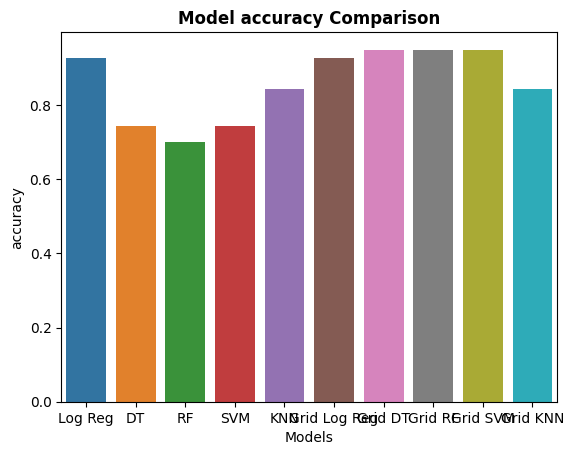

Wilcoxon signed-rank test for precision

Methods without fine tuning
Log Reg    0.920782
DT         0.759279
RF         0.850418
SVM        0.759416
KNN         0.82337
Name: precision, dtype: object

Wilcoxon signed-rank test statistic: 0.0
p-value: 0.125

Methods with best parameters
Grid Log Reg    0.921775
Grid DT         0.944175
Grid RF         0.943495
Grid SVM        0.944739
Grid KNN         0.82337
Name: precision, dtype: object

Wilcoxon signed-rank test statistic: 0.0
p-value: 0.03125

Overall methods
Log Reg         0.920782
DT              0.759279
RF              0.850418
SVM             0.759416
KNN              0.82337
Grid Log Reg    0.921775
Grid DT         0.944175
Grid RF         0.943495
Grid SVM        0.944739
Grid KNN         0.82337
Name: precision, dtype: object

Wilcoxon signed-rank test statistic: 0.0
p-value: 0.001953125


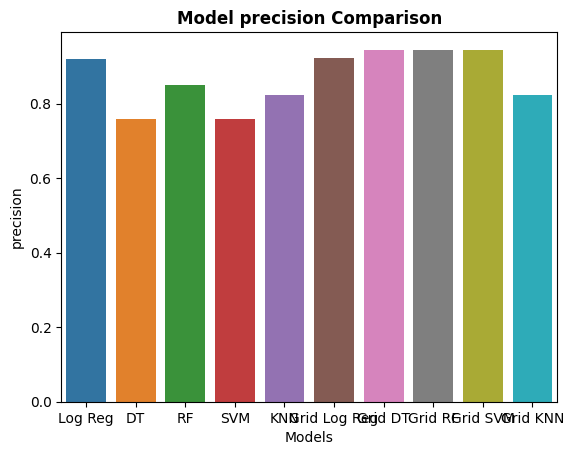

Wilcoxon signed-rank test for recall

Methods without fine tuning
Log Reg    0.904651
DT         0.586553
RF         0.501135
SVM        0.586515
KNN        0.879465
Name: recall, dtype: object

Wilcoxon signed-rank test statistic: 0.0
p-value: 0.125

Methods with best parameters
Grid Log Reg    0.905395
Grid DT          0.93362
Grid RF         0.934174
Grid SVM        0.933811
Grid KNN        0.879465
Name: recall, dtype: object

Wilcoxon signed-rank test statistic: 0.0
p-value: 0.03125

Overall methods
Log Reg         0.904651
DT              0.586553
RF              0.501135
SVM             0.586515
KNN             0.879465
Grid Log Reg    0.905395
Grid DT          0.93362
Grid RF         0.934174
Grid SVM        0.933811
Grid KNN        0.879465
Name: recall, dtype: object

Wilcoxon signed-rank test statistic: 0.0
p-value: 0.001953125


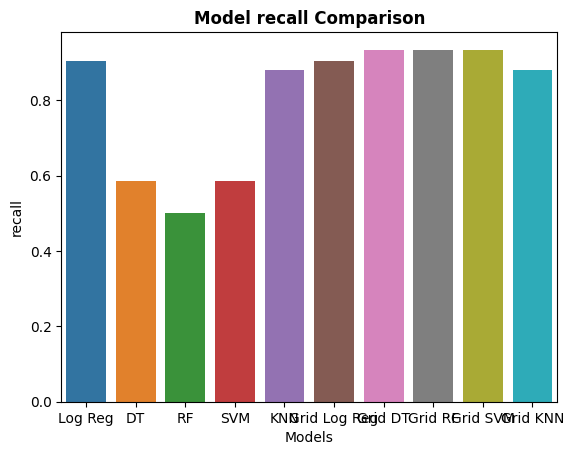

Wilcoxon signed-rank test for f1-score

Methods without fine tuning
Log Reg    0.912153
DT         0.578046
RF         0.414318
SVM        0.577977
KNN        0.831517
Name: f1-score, dtype: object

Wilcoxon signed-rank test statistic: 0.0
p-value: 0.125

Methods with best parameters
Grid Log Reg    0.913005
Grid DT         0.938669
Grid RF         0.938655
Grid SVM         0.93903
Grid KNN        0.831517
Name: f1-score, dtype: object

Wilcoxon signed-rank test statistic: 0.0
p-value: 0.03125

Overall methods
Log Reg         0.912153
DT              0.578046
RF              0.414318
SVM             0.577977
KNN             0.831517
Grid Log Reg    0.913005
Grid DT         0.938669
Grid RF         0.938655
Grid SVM         0.93903
Grid KNN        0.831517
Name: f1-score, dtype: object

Wilcoxon signed-rank test statistic: 0.0
p-value: 0.001953125


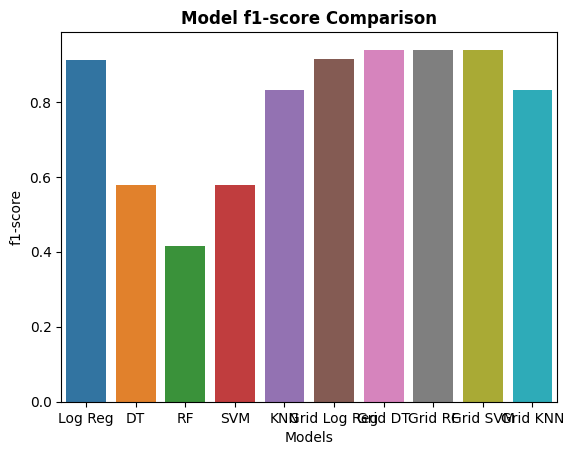

In [29]:
compareModels(testModelMetrics)